# Dataset Audit

## Project

MaternalRisk: Early Prediction of Gestational Diabetes Using Explainable Machine Learning

**Author:** Kristen Cranford

**Date:** July 2026

---

## Objective

The purpose of this notebook is to assess the quality, structure, and completeness of the gestational diabetes dataset before any preprocessing or modeling.

This audit will identify:

- Dataset dimensions
- Variable types
- Missing values
- Duplicate records
- Potential data quality issues
- Potential sources of data leakage
- Initial observations that may influence downstream analysis

# Clinical Context

Gestational diabetes mellitus (GDM) is typically diagnosed through routine glucose screening performed during the second trimester of pregnancy. Earlier identification of patients at elevated risk may allow clinicians to recommend lifestyle interventions, closer monitoring, or earlier diagnostic testing.

This project investigates whether routinely collected information available during the first prenatal visit can support early risk prediction using explainable machine learning methods.

In [103]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

In [104]:
# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Improve plot resolution
plt.rcParams["figure.dpi"] = 120

In [105]:
DATA_PATH = Path("../data/raw/Gestational Diabetic Dat Set.xlsx")

df = pd.read_excel(DATA_PATH)

## Dataset Overview

In [106]:
df.shape

(3525, 17)

In [107]:
df.head()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
0,1,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,2,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,3,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,4,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,5,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


In [108]:
df.tail()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
3520,3521,31,4,1,24.1,32.0,0,0,1,0,150.0,107,187.0,13.4,1,1,1
3521,3522,26,3,1,34.5,43.0,1,1,0,1,166.0,85,164.0,14.2,0,0,1
3522,3523,35,2,2,23.6,56.0,1,0,1,0,178.0,81,141.0,15.3,0,1,1
3523,3524,37,2,0,23.3,28.0,1,0,1,1,139.0,115,133.0,13.3,0,1,0
3524,3525,43,2,0,28.6,30.0,1,1,0,0,121.0,63,179.0,15.8,1,0,0


In [109]:
df.sample(5)

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
2271,2272,30,4,2,28.9,NaN,1,1,1,1,NaN,80,219.0,14.9,1,1,1
849,850,36,2,1,NaN,60.0,0,1,0,0,NaN,60,156.0,14.0,1,0,0
3192,3193,39,1,0,35.5,23.0,1,0,1,1,143.0,113,222.0,15.1,0,1,1
978,979,32,3,1,NaN,41.0,1,0,1,0,NaN,83,156.0,13.0,1,0,0
2385,2386,36,2,2,31.1,NaN,1,1,1,1,154.0,83,242.0,17.5,1,1,1


In [110]:
df.sample(5, random_state=42)

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
325,326,33,2,1,NaN,45.0,1,0,0,0,123.0,81,NaN,12.3,0,0,0
2339,2340,26,3,2,30.1,NaN,1,1,1,1,178.0,86,219.0,16.1,1,1,1
3413,3414,26,3,2,28.5,68.0,1,1,0,1,168.0,74,161.0,15.3,1,0,0
746,747,31,2,1,NaN,44.0,1,1,0,0,NaN,80,102.0,12.0,1,0,0
299,300,30,2,1,NaN,45.0,1,0,0,0,120.0,83,NaN,14.0,0,0,0


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No of Pregnancy                  3525 non-null   int64  
 3   Gestation in previous Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family History                   3525 non-null   int64  
 7   unexplained prenetal loss        3525 non-null   int64  
 8   Large Child or Birth Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys BP                           1820 non-null   float64
 11  Dia BP                           3525 non-null   int64  
 12  OGTT                           

## Observation

The dataset contains 3,525 patient records and 17 variables. Initial inspection suggests a mixture of demographic characteristics, clinical measurements, medical history, and a binary outcome indicating gestational diabetes status.

## Feature Inventory

| Feature | Description | Type | Available at First Prenatal Visit? | Leakage Risk |
|---------|-------------|------|------------------------------------|--------------|
| Age | Maternal age (years) | Numeric | Yes | No |
| No of Pregnancies | Total number of previous pregnancies | Numeric | Yes | No |
| Gestation in Previous Pregnancy | Gestational age (weeks) of the previous pregnancy | Numeric | Yes | No |
| BMI | Body Mass Index (kg/m²) | Numeric | Yes | No |
| HDL | High-density lipoprotein ("good" cholesterol) | Numeric | Likely | No |
| Family History | Family history of diabetes | Binary | Yes | No |
| Unexplained Prenatal Loss | History of unexplained prenatal loss | Binary | Yes | No |
| Large Child or Birth Defect | History of delivering a macrosomic infant or previous birth defect | Binary | Yes | No |
| PCOS | History of polycystic ovary syndrome (PCOS) | Binary | Yes | No |
| Sys BP | Systolic blood pressure (mmHg) | Numeric | Yes | No |
| Dia BP | Diastolic blood pressure (mmHg) | Numeric | Yes | No |
| OGTT | Oral Glucose Tolerance Test result | Numeric | No | **High** |
| Hemoglobin | Maternal hemoglobin level | Numeric | Likely | No |
| Sedentary Lifestyle | Indicator of sedentary lifestyle | Binary | Yes | No |
| Prediabetes | History of prediabetes | Binary | Yes | Low |
| Class Label (GDM / Non GDM) | Indicates whether the patient developed gestational diabetes | Target | No | **Target Variable** |
| Case Number | Unique patient identifier | Identifier | No | N/A |



### Notes

- "Available at First Prenatal Visit?" indicates whether the information would reasonably be available when the model is intended to make a prediction.
- Variables with high leakage risk were identified because they may not be available until after routine gestational diabetes screening or are directly related to the outcome being predicted.
- Feature descriptions are based on the dataset documentation and standard clinical terminology where available.

## Column Review

In [112]:
df.columns

Index(['Case Number', 'Age', 'No of Pregnancy',
       'Gestation in previous Pregnancy', 'BMI', 'HDL', 'Family History',
       'unexplained prenetal loss', 'Large Child or Birth Default', 'PCOS',
       'Sys BP', 'Dia BP', 'OGTT', 'Hemoglobin', 'Sedentary Lifestyle',
       'Prediabetes', 'Class Label(GDM /Non GDM)'],
      dtype='str')

## Data Types

In [113]:
df.dtypes

Case Number                          int64
Age                                  int64
No of Pregnancy                      int64
Gestation in previous Pregnancy      int64
BMI                                float64
HDL                                float64
Family History                       int64
unexplained prenetal loss            int64
Large Child or Birth Default         int64
PCOS                                 int64
Sys BP                             float64
Dia BP                               int64
OGTT                               float64
Hemoglobin                         float64
Sedentary Lifestyle                  int64
Prediabetes                          int64
Class Label(GDM /Non GDM)            int64
dtype: object

In [114]:
df.dtypes.value_counts()

int64      12
float64     5
Name: count, dtype: int64

In [115]:
# Number of unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Case Number: 3525 unique values
Age: 26 unique values
No of Pregnancy: 4 unique values
Gestation in previous Pregnancy: 3 unique values
BMI: 272 unique values
HDL: 56 unique values
Family History: 2 unique values
unexplained prenetal loss: 2 unique values
Large Child or Birth Default: 2 unique values
PCOS: 2 unique values
Sys BP: 96 unique values
Dia BP: 65 unique values
OGTT: 252 unique values
Hemoglobin: 88 unique values
Sedentary Lifestyle: 2 unique values
Prediabetes: 2 unique values
Class Label(GDM /Non GDM): 2 unique values


## Missing Data

In [116]:
df.isnull().sum()

Case Number                           0
Age                                   0
No of Pregnancy                       0
Gestation in previous Pregnancy       0
BMI                                1081
HDL                                1001
Family History                        0
unexplained prenetal loss             0
Large Child or Birth Default          0
PCOS                                  0
Sys BP                             1705
Dia BP                                0
OGTT                                513
Hemoglobin                            0
Sedentary Lifestyle                   0
Prediabetes                           0
Class Label(GDM /Non GDM)             0
dtype: int64

In [117]:
missing_count = df.isnull().sum()

missing_count = missing_count[missing_count > 0]

missing_count.sort_values(ascending=False)

Sys BP    1705
BMI       1081
HDL       1001
OGTT       513
dtype: int64

In [118]:
missing_percent = (df.isnull().mean() * 100)

missing_percent = missing_percent[missing_percent > 0]

missing_summary = (
    pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage": missing_percent
    })
    .sort_values("Missing Percentage", ascending=False)
)

display(missing_summary)

,Missing Count,Missing Percentage
Sys BP,1705,48.368794
BMI,1081,30.666667
HDL,1001,28.397163
OGTT,513,14.553191


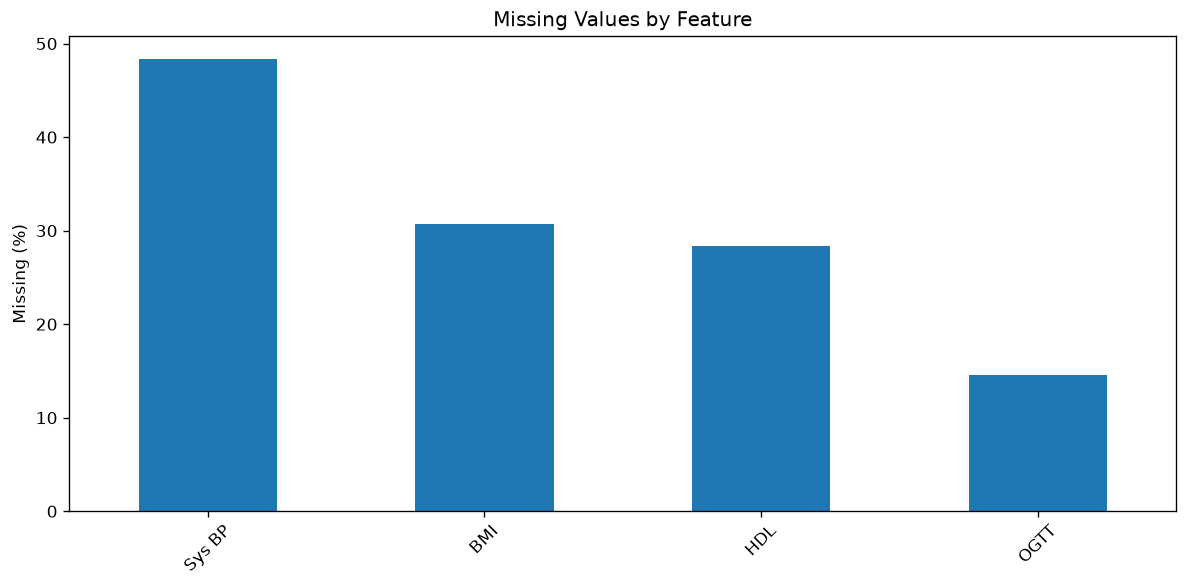

In [119]:
missing_summary["Missing Percentage"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Missing (%)")
plt.title("Missing Values by Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations
Four variables contain missing values. Systolic blood pressure has the highest proportion of missing data (48.37%), followed by BMI (30.67%), HDL (28.40%), and OGTT (14.55%). What stood out the most was that Sys BP is missing in almost half of the samples, with a total of 1705 missing samples. BMI and HDL have roughly the same amount of missing samples, and OGTT has the lowest. 

Because these variables are clinically important, the missingness could affect downstream analyses and predictive model performance. The missing values may reflect differences in clinical workflow, incomplete testing, or missing documentation rather than data entry errors. Additional investigation is needed to determine whether the missingness is random before selecting an imputation strategy.

Missing systolic blood pressure values reduce the amount of information available to the predictive model. Because blood pressure is an established cardiovascular risk factor, understanding the mechanism behind this missingness will be important when selecting an imputation strategy.

BMI can be an indicator for diabetes, especially in pregnant women since you naturally gain weight during pregnancy. Missing BMI could cause under diagnosis of gestational diabetes. The same goes for HDL

The most interesting thing to notice is missing values for OGTT. OGTT is the actual test used to determine if a mother has gestational diabetes. Because OGTT is commonly used to diagnose gestational diabetes, missing OGTT values may reflect differences in clinical workflow, incomplete testing, or missing documentation. Further investigation is needed before deciding how to handle these values.

# Duplicate Data

In [120]:
df.duplicated().sum()

np.int64(0)

## Target Variable

The target variable is Class Label (GDM / Non GDM), which indicates whether a patient developed gestational diabetes. The Case Number appears to be a unique identifier and will not be used as a predictive feature.

In [121]:
target = "Class Label(GDM /Non GDM)"

# Counts
target_counts = df[target].value_counts()
print(target_counts)

# Percentages
target_percent = (
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percent)

Class Label(GDM /Non GDM)
0    2153
1    1372
Name: count, dtype: int64
Class Label(GDM /Non GDM)
0    61.08
1    38.92
Name: proportion, dtype: float64


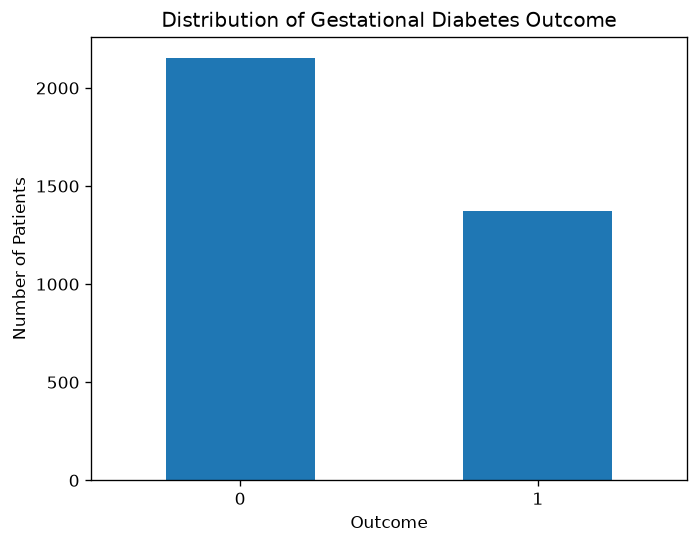

In [122]:
target_counts.plot(kind="bar")

plt.title("Distribution of Gestational Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

## Observations

The dataset exhibits moderate class imbalance, with approximately 61% GDM cases and 39% non-GDM cases. This distribution is not severe, but it reinforces the need to evaluate models using metrics beyond accuracy.

## Summary Statistics

In [123]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Case Number,3525.0,1763.000000,1017.724177,1.0,882.0,1763.0,2644.0,3525.0
Age,3525.0,32.581277,6.169107,20.0,28.0,32.0,37.0,45.0
No of Pregnancy,3525.0,2.076312,0.838637,1.0,1.0,2.0,3.0,4.0
Gestation in previous Pregnancy,3525.0,0.960851,0.722313,0.0,0.0,1.0,1.0,2.0
BMI,2444.0,27.854092,5.714737,13.3,24.4,27.5,31.0,45.0
HDL,2524.0,46.471870,10.800813,15.0,42.0,49.0,55.0,70.0
Family History,3525.0,0.498156,0.500068,0.0,0.0,0.0,1.0,1.0
unexplained prenetal loss,3525.0,0.364823,0.481449,0.0,0.0,0.0,1.0,1.0
Large Child or Birth Default,3525.0,0.357730,0.479400,0.0,0.0,0.0,1.0,1.0
PCOS,3525.0,0.264681,0.441226,0.0,0.0,0.0,1.0,1.0


## Observations

The summary statistics suggest that maternal age falls within a plausible reproductive range, with no immediately obvious impossible values. BMI values should be reviewed for unusually low or extremely high observations that may represent outliers or recording errors. Blood pressure measurements should also be examined for physiologically implausible values, particularly zeros or extremely low readings. Overall, no obvious data entry errors were identified from the descriptive statistics alone, but additional validation will be performed during preprocessing.

In [124]:
display(df.describe(include="all").T)

,count,mean,std,min,25%,50%,75%,max
Case Number,3525.0,1763.000000,1017.724177,1.0,882.0,1763.0,2644.0,3525.0
Age,3525.0,32.581277,6.169107,20.0,28.0,32.0,37.0,45.0
No of Pregnancy,3525.0,2.076312,0.838637,1.0,1.0,2.0,3.0,4.0
Gestation in previous Pregnancy,3525.0,0.960851,0.722313,0.0,0.0,1.0,1.0,2.0
BMI,2444.0,27.854092,5.714737,13.3,24.4,27.5,31.0,45.0
HDL,2524.0,46.471870,10.800813,15.0,42.0,49.0,55.0,70.0
Family History,3525.0,0.498156,0.500068,0.0,0.0,0.0,1.0,1.0
unexplained prenetal loss,3525.0,0.364823,0.481449,0.0,0.0,0.0,1.0,1.0
Large Child or Birth Default,3525.0,0.357730,0.479400,0.0,0.0,0.0,1.0,1.0
PCOS,3525.0,0.264681,0.441226,0.0,0.0,0.0,1.0,1.0


In [125]:
# Age
df["Age"].describe()


count    3525.000000
mean       32.581277
std         6.169107
min        20.000000
25%        28.000000
50%        32.000000
75%        37.000000
max        45.000000
Name: Age, dtype: float64

In [126]:
# BMI
df["BMI"].describe()


count    2444.000000
mean       27.854092
std         5.714737
min        13.300000
25%        24.400000
50%        27.500000
75%        31.000000
max        45.000000
Name: BMI, dtype: float64

In [127]:
# Blood pressure
df[["Sys BP", "Dia BP"]].describe()

,Sys BP,Dia BP
count,1820.000000,3525.000000
mean,135.762088,81.538156
std,22.742844,11.379758
min,90.000000,60.000000
25%,122.000000,74.000000
50%,132.000000,81.000000
75%,153.000000,86.000000
max,185.000000,124.000000


In [128]:
# Implausible values

df[df["Age"] < 12]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [129]:

df[df["Age"] > 55]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [130]:

df[df["BMI"] < 10]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [131]:
df[df["BMI"] > 70]


,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [132]:
df[df["Sys BP"] <= 0]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [133]:
df[df["Dia BP"] <= 0]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [134]:
# Check unusual values
# Negative BMI
df[df["BMI"] < 0]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [135]:
# Zero blood pressure
df[df["Sys BP"] == 0]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


In [136]:
# Zero blood pressure
df[df["Dia BP"] == 0]

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)


Systolic blood pressure contains the highest proportion of missing values (48.37%), followed by BMI (30.67%), HDL (28.40%), and OGTT (14.55%).

## Potential Data Leakage

| Feature        | Available During First Prenatal Visit? | Keep for Primary Model? | Notes                                                                            |
| -------------- | -------------------------------------- | ----------------------- | -------------------------------------------------------------------------------- |
| Case Number    | Yes                                    | No                      | Unique identifier with no predictive value.                                      |
| Age            | Yes                                    | Yes                     | Available from patient demographics.                                             |
| BMI            | Yes                                    | Yes                     | Collected during the initial prenatal assessment.                                |
| Family History | Yes                                    | Yes                     | Known before pregnancy.                                                          |
| PCOS           | Yes                                    | Yes                     | Pre-existing diagnosis.                                                          |
| Prediabetes    | Yes*                                   | Yes                     | Assumed to represent a diagnosis prior to pregnancy; timing should be confirmed. |
| OGTT           | No                                     | No                      | Diagnostic glucose tolerance test that may introduce target leakage.             |


OGTT was identified as the primary leakage risk because it is commonly used during diagnostic screening for gestational diabetes. Including this variable in a model intended to predict GDM at the first prenatal visit would likely inflate model performance by providing information unavailable at prediction time.

## Key Findings

- The dataset contains 3,525 observations and 17 variables.
- Most predictors are numeric clinical measurements and patient history variables.
- Missing values are concentrated in Sys BP, BMI, HDL, and OGTT.
- No duplicate records were identified.
- The target variable is the GDM class label.
- Case Number is an identifier and will be excluded from modeling.
- OGTT presents a high risk of target leakage and will not be included in the primary predictive model.

## Sprint Retrospective

### What went well

- Successfully documented dataset structure and quality.
- Identified missing data and potential leakage.
- Defined the prediction point for the project.

### Challenges

- Interpreting the timing of certain clinical variables.
- Distinguishing observation from interpretation.

### Next Sprint

Investigate missingness patterns and develop a reproducible preprocessing pipeline.

## Questions Raised During the Audit

1. Why are nearly half of the systolic blood pressure values missing?
2. Was OGTT measured before or after the diagnosis of gestational diabetes?
3. Does the Prediabetes variable represent a diagnosis established before pregnancy?
4. Are the missing values random, or are they associated with specific patient characteristics?
5. Should HDL, BMI, and blood pressure be imputed or excluded during preprocessing?
6. Are all records collected from the same healthcare setting or from multiple hospitals?